In [1]:
%pip install pandas numpy matplotlib scikit-learn lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("datasets/train.csv")
test = pd.read_csv("datasets/test.csv")

train.head()

,id,publish_date,weekday,channel,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,target
0,0,2013-01-07,Monday,Entertainment,12.0,219.0,0.663594,1.0,0.815385,4.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,1,2013-01-07,Monday,Business,9.0,255.0,0.604743,1.0,0.791946,3.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,2,2013-01-07,Monday,Business,9.0,211.0,0.575130,1.0,0.663866,3.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,3,2013-01-07,Monday,Entertainment,9.0,531.0,0.503788,1.0,0.665635,9.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,4,2013-01-07,Monday,Tech,13.0,1072.0,0.415646,1.0,0.540890,19.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


## EDA

In [3]:
missing = train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [4]:
train["target"].value_counts(normalize=True) * 100

target
1    54.728047
0    45.271953
Name: proportion, dtype: float64

In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,31715.0,15857.000000,9155.476230,0.00000,7928.500000,15857.000000,23785.500000,31714.000000
n_tokens_title,31715.0,10.216617,2.059007,2.00000,9.000000,10.000000,12.000000,19.000000
n_tokens_content,31715.0,545.006275,472.320076,0.00000,245.000000,403.000000,706.000000,8474.000000
n_unique_tokens,31715.0,0.564569,3.935137,0.00000,0.476367,0.545455,0.614939,701.000000
n_non_stop_words,31715.0,1.018446,5.846748,0.00000,1.000000,1.000000,1.000000,1042.000000
n_non_stop_unique_tokens,31715.0,0.705974,3.648413,0.00000,0.629921,0.694915,0.759398,650.000000
num_hrefs,31715.0,11.120132,11.250545,0.00000,5.000000,8.000000,14.000000,187.000000
num_self_hrefs,31715.0,3.437080,3.951435,0.00000,1.000000,3.000000,4.000000,74.000000
num_imgs,31715.0,4.734038,8.618716,0.00000,1.000000,1.000000,5.000000,128.000000
num_videos,31715.0,1.260728,4.192666,0.00000,0.000000,0.000000,1.000000,91.000000


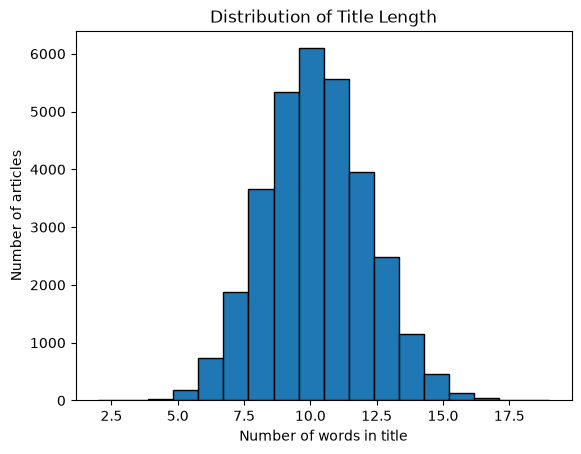

In [6]:
plt.hist(train["n_tokens_title"], bins=18, edgecolor="black")

plt.xlabel("Number of words in title")
plt.ylabel("Number of articles")
plt.title("Distribution of Title Length")

plt.show()

In [7]:
numeric_cols = train.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if col not in ["id", "target"]:
        means = train.groupby("target")[col].mean()

        print(f"\n{col}")
        print("Not popular:", round(means[0], 4))
        print("Popular:    ", round(means[1], 4))
        print("Difference: ", round(means[1] - means[0], 4))


n_tokens_title
Not popular: 10.3082
Popular:     10.1409
Difference:  -0.1673

n_tokens_content
Not popular: 515.9564
Popular:     569.0368
Difference:  53.0804

n_unique_tokens
Not popular: 0.5503
Popular:     0.5764
Difference:  0.0261

n_non_stop_words
Not popular: 0.987
Popular:     1.0445
Difference:  0.0575

n_non_stop_unique_tokens
Not popular: 0.6943
Popular:     0.7156
Difference:  0.0213

num_hrefs
Not popular: 10.0507
Popular:     12.0048
Difference:  1.9541

num_self_hrefs
Not popular: 3.2944
Popular:     3.5551
Difference:  0.2607

num_imgs
Not popular: 4.1724
Popular:     5.1987
Difference:  1.0263

num_videos
Not popular: 1.196
Popular:     1.3143
Difference:  0.1183

average_token_length
Not popular: 4.6337
Popular:     4.6055
Difference:  -0.0282

num_keywords
Not popular: 7.1825
Popular:     7.3861
Difference:  0.2035

kw_min_min
Not popular: 28.9914
Popular:     36.1035
Difference:  7.112

kw_max_min
Not popular: 1106.302
Popular:     1297.136
Difference:  190.834



In [8]:
print(pd.crosstab(
    train["channel"],
    train["target"],
    normalize="index"
) * 100)

print()

print(pd.crosstab(
    train["weekday"],
    train["target"],
    normalize="index"
) * 100)

target                 0          1
channel                            
Business       47.084356  52.915644
Entertainment  57.804522  42.195478
Lifestyle      37.900552  62.099448
Other          36.567318  63.432682
Social Media   23.451537  76.548463
Tech           35.816114  64.183886
World          59.264282  40.735718

target             0          1
weekday                        
Friday     43.657947  56.342053
Monday     48.107494  51.892506
Saturday   22.607346  77.392654
Sunday     29.968167  70.031833
Thursday   48.305229  51.694771
Tuesday    49.329486  50.670514
Wednesday  49.966600  50.033400


In [9]:
numeric_cols = train.select_dtypes(include=np.number).columns.drop(["id", "target"])

skewness = train[numeric_cols].skew().sort_values(ascending=False)

skewness

n_non_stop_words                177.976249
n_unique_tokens                 177.828337
n_non_stop_unique_tokens        177.741315
kw_max_min                       34.631660
kw_avg_min                       30.959646
self_reference_min_shares        25.070864
self_reference_avg_shares        16.964198
kw_max_avg                       16.788854
self_reference_max_shares        13.193551
kw_min_max                       10.927229
num_videos                        7.110549
kw_avg_avg                        6.249552
num_self_hrefs                    4.607213
num_imgs                          3.865845
num_hrefs                         3.744792
n_tokens_content                  3.099446
min_positive_polarity             3.078721
LDA_01                            2.089786
kw_min_min                        1.995164
abs_title_sentiment_polarity      1.695455
global_rate_negative_words        1.631916
LDA_00                            1.460983
LDA_02                            1.428369
LDA_03     

## Cleaning


In [10]:
ratio_cols = ["n_unique_tokens", "n_non_stop_words", "n_non_stop_unique_tokens"]

train[ratio_cols].max()

n_unique_tokens              701.0
n_non_stop_words            1042.0
n_non_stop_unique_tokens     650.0
dtype: float64

In [11]:
lda_cols = [f"LDA_0{i}" for i in range(5)]


def clean(df):
    df = df.copy()

    # clip the broken ratio values
    for col in ratio_cols:
        df[col] = df[col].clip(upper=1)

    # n_non_stop_words is ~1 for every row -> no information
    df = df.drop(columns=["n_non_stop_words"])

    df["publish_date"] = pd.to_datetime(df["publish_date"])

    # --- new features ---
    df["lda_top"] = df[lda_cols].values.argmax(axis=1)   # dominant topic
    df["lda_max"] = df[lda_cols].max(axis=1)
    df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"]).astype(int)
    df["chan_weekend"] = df["channel"] + "_" + df["is_weekend"].astype(str)
    df["hrefs_per_word"] = df["num_hrefs"] / (df["n_tokens_content"] + 1)
    df["imgs_per_word"] = df["num_imgs"] / (df["n_tokens_content"] + 1)
    df["kw_avg_ratio"] = df["kw_avg_avg"] / (df["kw_max_avg"] + 1)
    df["month"] = df["publish_date"].dt.month   # month only, never the raw date
    return df


train = clean(train)
test = clean(test)

train[["n_unique_tokens", "n_non_stop_unique_tokens"]].skew()

n_unique_tokens            -1.014348
n_non_stop_unique_tokens   -2.081454
dtype: float64

## Time-based split



In [12]:
print("train:", train["publish_date"].min(), "→", train["publish_date"].max())
print("test: ", test["publish_date"].min(), "→", test["publish_date"].max())

train: 2013-01-07 00:00:00 → 2014-08-28 00:00:00
test:  2014-08-28 00:00:00 → 2014-12-27 00:00:00


In [13]:
train = train.sort_values("publish_date").reset_index(drop=True)

split_idx = int(len(train) * 0.8)

cutoff_date = train.iloc[split_idx]["publish_date"]

train_part = train[train["publish_date"] < cutoff_date].copy()
val_part   = train[train["publish_date"] >= cutoff_date].copy()

print(train_part["publish_date"].min(), "→", train_part["publish_date"].max())
print(val_part["publish_date"].min(), "→", val_part["publish_date"].max())

print(len(train_part), len(val_part))

2013-01-07 00:00:00 → 2014-05-15 00:00:00
2014-05-16 00:00:00 → 2014-08-28 00:00:00
25311 6404


In [14]:
drop_cols = ["target", "id", "publish_date"]

X_train = train_part.drop(columns=drop_cols)
y_train = train_part["target"]

X_val = val_part.drop(columns=drop_cols)
y_val = val_part["target"]

X_full = train.drop(columns=drop_cols)
y_full = train["target"]

X_test = test.drop(columns=["id", "publish_date"])

In [15]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ["weekday", "channel", "chan_weekend"]
linear_cat_cols = cat_cols + ["lda_top", "month"]

log_cols = [
    "kw_max_min",
    "kw_avg_min",
    "self_reference_min_shares",
    "self_reference_avg_shares",
    "kw_max_avg",
    "self_reference_max_shares",
    "kw_min_max",
    "num_videos",
    "kw_avg_avg",
    "num_self_hrefs",
    "num_imgs",
    "num_hrefs",
    "n_tokens_content"
]

other_cols = [c for c in X_train.columns if c not in linear_cat_cols + log_cols]


def safe_log1p(x):
    # kw_avg_min has some -1 values
    return np.log1p(np.clip(x, 0, None))


linear_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), linear_cat_cols),
        ("log", Pipeline([
            ("log", FunctionTransformer(safe_log1p)),
            ("scale", StandardScaler())
        ]), log_cols),
        ("num", StandardScaler(), other_cols)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# LightGBM wants pandas "category" dtype with the same categories everywhere
cat_dtypes = {c: pd.CategoricalDtype(sorted(train[c].unique())) for c in cat_cols}


def as_lgb(df):
    df = df.copy()
    for c in cat_cols:
        df[c] = df[c].astype(cat_dtypes[c])
    return df

In [16]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

models = {
    "Logistic Regression": Pipeline([
        ("prep", linear_preprocessor),
        ("model", LogisticRegression(max_iter=3000))
    ]),

    "PCA + Logistic Regression": Pipeline([
        ("prep", linear_preprocessor),
        ("pca", PCA(n_components=0.95)),   # keep 95% of variance
        ("model", LogisticRegression(max_iter=3000))
    ]),

    "Random Forest": Pipeline([
        ("prep", tree_preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=42))
    ]),

    "Extra Trees": Pipeline([
        ("prep", tree_preprocessor),
        ("model", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=42))
    ]),

    "HistGradientBoosting": Pipeline([
        ("prep", tree_preprocessor),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=50,
            l2_regularization=1.0,
            early_stopping=False,   # default turns ON for >10k rows
            random_state=42
        ))
    ]),
}

In [17]:
from sklearn.metrics import accuracy_score, roc_auc_score

results = []
val_probs = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]
    val_probs[name] = y_prob

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_val, (y_prob >= 0.5).astype(int)),
        "roc_auc": roc_auc_score(y_val, y_prob)
    })

pd.DataFrame(results).sort_values("roc_auc", ascending=False)

,model,accuracy,roc_auc
2,Random Forest,0.688944,0.750544
4,HistGradientBoosting,0.684728,0.749052
3,Extra Trees,0.684884,0.739851
0,Logistic Regression,0.660681,0.735491
1,PCA + Logistic Regression,0.674578,0.724215


In [18]:
%pip install lightgbm catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
    --------------------------------------- 1.8/100.2 MB 7.2 MB/s eta 0:00:14
   - -------------------------------------- 3.7/100.2 MB 9.5 MB/s eta 0:00:11
   -- ------------------------------------- 6.8/100.2 MB 10.5 MB/s eta 0:00:09
   --- ------------------------------------ 9.4/100.2 MB 10.7 MB/s eta 0:00:09
   ---- ----------------------------------- 11.0/100.2 MB 10.0 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/100.2 MB 11.1 MB/s eta 0:00:08
   ------ --------------------------------- 16.8/100.2 MB 11.1 MB/s eta 0:00:08
   ------- -------------------------------- 19.4/100.2 MB 11.2 MB/s eta 0:00:08
   -------- ------------------------------- 22.0/100.2 MB 11.3 MB/s eta 0:00:07
   --------- ------------------------------ 24.6/100.2 MB 11.3 MB/s eta 0:00:07
   ---------- ----------------------------- 26.7/100.2 MB 11.3 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## LightGBM and CatBoost with early stopping

Note: early stopping uses the validation set, so these two scores are slightly optimistic. The CV section below gives a fairer number.

In [19]:
import lightgbm as lgb

lgb_params = dict(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.5,
    reg_lambda=5.0,
    random_state=42,
    verbose=-1
)

lgbm = lgb.LGBMClassifier(**lgb_params)
lgbm.fit(
    as_lgb(X_train), y_train,
    eval_set=[(as_lgb(X_val), y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(200, verbose=False)]
)

lgb_best_iter = lgbm.best_iteration_
val_probs["LightGBM"] = lgbm.predict_proba(as_lgb(X_val))[:, 1]

print("best iteration:", lgb_best_iter)
print("val AUC:", round(roc_auc_score(y_val, val_probs["LightGBM"]), 4))

c:\Users\User\miniconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


best iteration: 1105
val AUC: 0.7553


In [20]:
train["target"].value_counts(normalize=True) * 100

target
1    54.728047
0    45.271953
Name: proportion, dtype: float64

In [21]:
from catboost import CatBoostClassifier

cat_params = dict(
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

catb = CatBoostClassifier(iterations=5000, od_type="Iter", od_wait=200, **cat_params)
catb.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_val, y_val), use_best_model=True)

cat_best_iter = catb.get_best_iteration()
val_probs["CatBoost"] = catb.predict_proba(X_val)[:, 1]

print("best iteration:", cat_best_iter)
print("val AUC:", round(roc_auc_score(y_val, val_probs["CatBoost"]), 4))

best iteration: 776
val AUC: 0.7552


## Rank blend

AUC only cares about ordering, so averaging ranks is safe even if the models' probabilities are on different scales.

In [22]:
from scipy.stats import rankdata

blend_weights = {"LightGBM": 0.5, "CatBoost": 0.3, "Logistic Regression": 0.2}


def rank_blend(probs):
    out = sum(w * rankdata(probs[name]) for name, w in blend_weights.items())
    return out / out.max()


val_probs["Blend"] = rank_blend(val_probs)

for name in ["LightGBM", "CatBoost", "Blend"]:
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_val, (val_probs[name] >= 0.5).astype(int)) if name != "Blend" else np.nan,
        "roc_auc": roc_auc_score(y_val, val_probs[name])
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,roc_auc
0,Blend,NaN,0.757479
1,LightGBM,0.681605,0.755311
2,CatBoost,0.686758,0.755160
3,Random Forest,0.688944,0.750544
4,HistGradientBoosting,0.684728,0.749052
5,Extra Trees,0.684884,0.739851
6,Logistic Regression,0.660681,0.735491
7,PCA + Logistic Regression,0.674578,0.724215


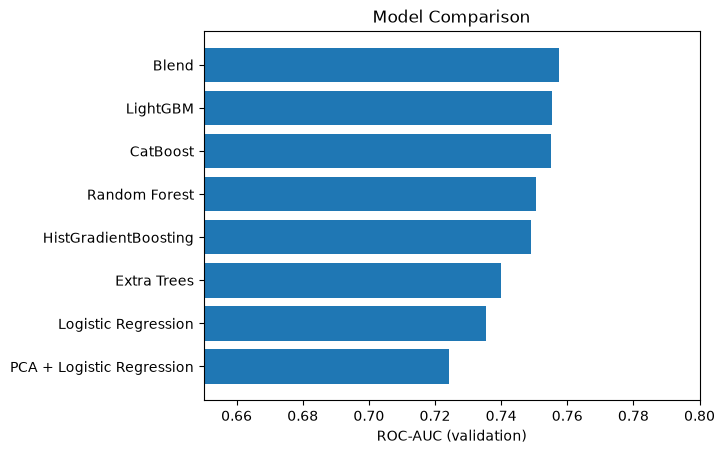

In [23]:
plt.barh(results_df["model"], results_df["roc_auc"])
plt.xlim(0.65, 0.80)
plt.xlabel("ROC-AUC (validation)")
plt.title("Model Comparison")
plt.gca().invert_yaxis()
plt.show()

## Time-series CV



In [24]:
from sklearn.model_selection import TimeSeriesSplit


def recency_weights(dates, scale_days=365):
    # newest article = 1, one year older ≈ 0.37
    days = (dates - dates.max()).dt.days
    return np.exp(days / scale_days).values


X_full_lgb = as_lgb(X_full)
tscv = TimeSeriesSplit(n_splits=4)   # train is already sorted by date

cv_rows = []
for fold, (tr, va) in enumerate(tscv.split(X_full)):
    w = recency_weights(train["publish_date"].iloc[tr])

    for weighted in [False, True]:
        m = lgb.LGBMClassifier(**{**lgb_params, "n_estimators": lgb_best_iter})
        m.fit(X_full_lgb.iloc[tr], y_full.iloc[tr], sample_weight=w if weighted else None)

        p = m.predict_proba(X_full_lgb.iloc[va])[:, 1]
        cv_rows.append({"fold": fold, "weighted": weighted, "auc": roc_auc_score(y_full.iloc[va], p)})

cv = pd.DataFrame(cv_rows)
cv_mean = cv.groupby("weighted")["auc"].mean()

print(cv.pivot(index="fold", columns="weighted", values="auc").round(4))
print()
print(cv_mean.round(4))

USE_WEIGHTS = cv_mean[True] > cv_mean[False]
print("\nUse recency weights:", USE_WEIGHTS)

weighted   False   True 
fold                    
0         0.7037  0.7043
1         0.7177  0.7176
2         0.7272  0.7254
3         0.7544  0.7555

weighted
False    0.7257
True     0.7257
Name: auc, dtype: float64

Use recency weights: False


## Final models on all training data


In [25]:
from sklearn.base import clone

w_full = recency_weights(train["publish_date"]) if USE_WEIGHTS else None
test_probs = {}

# 1. LightGBM
final_lgb = lgb.LGBMClassifier(**{**lgb_params, "n_estimators": int(lgb_best_iter * 1.2)})
final_lgb.fit(X_full_lgb, y_full, sample_weight=w_full)
test_probs["LightGBM"] = final_lgb.predict_proba(as_lgb(X_test))[:, 1]

# 2. CatBoost
final_cat = CatBoostClassifier(iterations=int(cat_best_iter * 1.2), **cat_params)
final_cat.fit(X_full, y_full, cat_features=cat_cols, sample_weight=w_full)
test_probs["CatBoost"] = final_cat.predict_proba(X_test)[:, 1]

# 3. Logistic Regression
final_lr = clone(models["Logistic Regression"])
final_lr.fit(X_full, y_full, model__sample_weight=w_full)
test_probs["Logistic Regression"] = final_lr.predict_proba(X_test)[:, 1]

In [26]:
# blend submission
submission = pd.DataFrame({"id": test["id"], "target": rank_blend(test_probs)})
submission.to_csv("submission_blend.csv", index=False)

# LightGBM-only submission, in case the blend does worse on the leaderboard
pd.DataFrame({"id": test["id"], "target": test_probs["LightGBM"]}).to_csv("submission_lgb.csv", index=False)

submission.head()

,id,target
0,31715,0.858644
1,31716,0.371126
2,31717,0.799735
3,31718,0.188180
4,31719,0.127304


In [27]:
# blend submission
submission = pd.DataFrame({"id": test["id"], "target": rank_blend(test_probs)})
submission.to_csv("submission_blend.csv", index=False)

# LightGBM-only submission, in case the blend does worse on the leaderboard
pd.DataFrame({"id": test["id"], "target": test_probs["CatBoost"]}).to_csv("submission_cat.csv", index=False)

submission.head()

,id,target
0,31715,0.858644
1,31716,0.371126
2,31717,0.799735
3,31718,0.188180
4,31719,0.127304
